# SARIMA(p,d,q)(P,D,Q)m
### Seasonal Autoregressive Integrated Moving Averages

Where ARIMA accepts the parameters $(p,d,q)$, SARIMA accepts an <em>additional</em> set of parameters $(P,D,Q)m$ that specifically describe the seasonal components of the model. Here $P$, $D$ and $Q$ represent the seasonal regression, differencing and moving average coefficients, and $m$ represents the number of data points (rows) in each seasonal cycle.

<strong>NOTE:</strong> The statsmodels implementation of SARIMA is called SARIMAX. The “X” added to the name means that the function also supports <em>exogenous</em> regressor variables.

#### 1) Importing Necessary Libraires:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from pmdarima import auto_arima

from sklearn.metrics import mean_squared_error

#### 2) Loading Data:

In [2]:
df = pd.read_csv('co2_mm_mlo.csv')

In [3]:
df.head()

,year,month,decimal_date,average,interpolated
0,1958,3,1958.208,315.71,315.71
1,1958,4,1958.292,317.45,317.45
2,1958,5,1958.375,317.50,317.50
3,1958,6,1958.458,NaN,317.10
4,1958,7,1958.542,315.86,315.86


##### Creating Date-Time Index from Data:

In [4]:
df['Date'] = pd.to_datetime({"year":df["year"], "month":df["month"], "day":1})

In [5]:
df['Date']

0     1958-03-01
1     1958-04-01
2     1958-05-01
3     1958-06-01
4     1958-07-01
         ...    
724   2018-07-01
725   2018-08-01
726   2018-09-01
727   2018-10-01
728   2018-11-01
Name: Date, Length: 729, dtype: datetime64[ns]

In [6]:
df.head()

,year,month,decimal_date,average,interpolated,Date
0,1958,3,1958.208,315.71,315.71,1958-03-01
1,1958,4,1958.292,317.45,317.45,1958-04-01
2,1958,5,1958.375,317.50,317.50,1958-05-01
3,1958,6,1958.458,NaN,317.10,1958-06-01
4,1958,7,1958.542,315.86,315.86,1958-07-01


In [7]:
df.set_index('Date', inplace= True)

In [8]:
df.head()

,year,month,decimal_date,average,interpolated
Date,,,,,
1958-03-01,1958,3,1958.208,315.71,315.71
1958-04-01,1958,4,1958.292,317.45,317.45
1958-05-01,1958,5,1958.375,317.50,317.50
1958-06-01,1958,6,1958.458,NaN,317.10
1958-07-01,1958,7,1958.542,315.86,315.86


##### Adding Index Frequency:

In [9]:
df.index

DatetimeIndex(['1958-03-01', '1958-04-01', '1958-05-01', '1958-06-01',
               '1958-07-01', '1958-08-01', '1958-09-01', '1958-10-01',
               '1958-11-01', '1958-12-01',
               ...
               '2018-02-01', '2018-03-01', '2018-04-01', '2018-05-01',
               '2018-06-01', '2018-07-01', '2018-08-01', '2018-09-01',
               '2018-10-01', '2018-11-01'],
              dtype='datetime64[ns]', name='Date', length=729, freq=None)

In [10]:
df.index.freq = 'MS'

In [11]:
df.index

DatetimeIndex(['1958-03-01', '1958-04-01', '1958-05-01', '1958-06-01',
               '1958-07-01', '1958-08-01', '1958-09-01', '1958-10-01',
               '1958-11-01', '1958-12-01',
               ...
               '2018-02-01', '2018-03-01', '2018-04-01', '2018-05-01',
               '2018-06-01', '2018-07-01', '2018-08-01', '2018-09-01',
               '2018-10-01', '2018-11-01'],
              dtype='datetime64[ns]', name='Date', length=729, freq='MS')

##### Plotting Data:

In [12]:
df.head()

,year,month,decimal_date,average,interpolated
Date,,,,,
1958-03-01,1958,3,1958.208,315.71,315.71
1958-04-01,1958,4,1958.292,317.45,317.45
1958-05-01,1958,5,1958.375,317.50,317.50
1958-06-01,1958,6,1958.458,NaN,317.10
1958-07-01,1958,7,1958.542,315.86,315.86


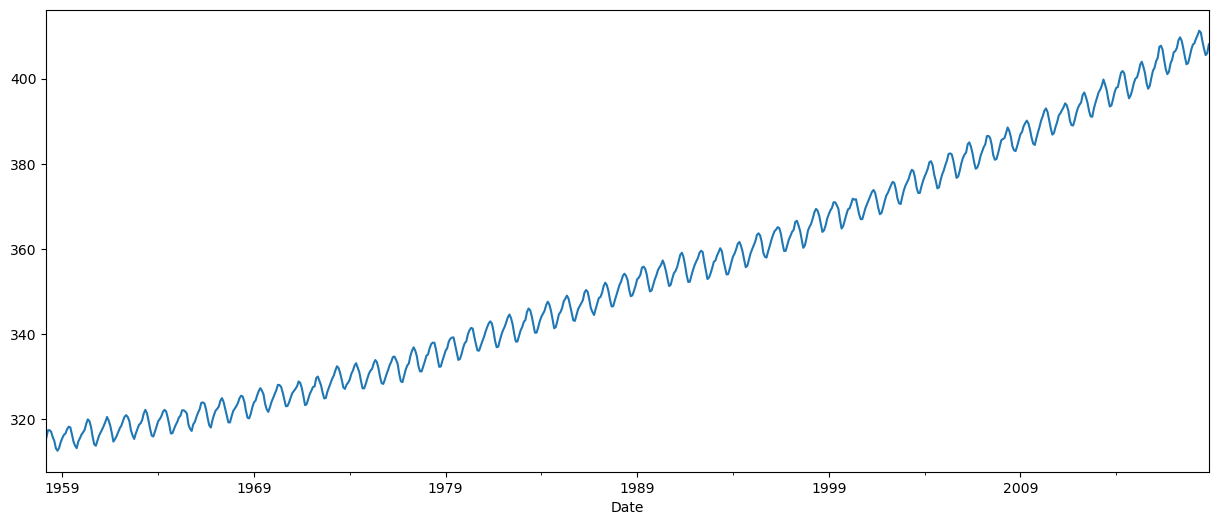

In [13]:
df['interpolated'].plot(figsize= (15,6))
plt.show()

#### 3) ETS Decomposition:

In [14]:
decomp = seasonal_decompose(df['interpolated'], model= 'additive')

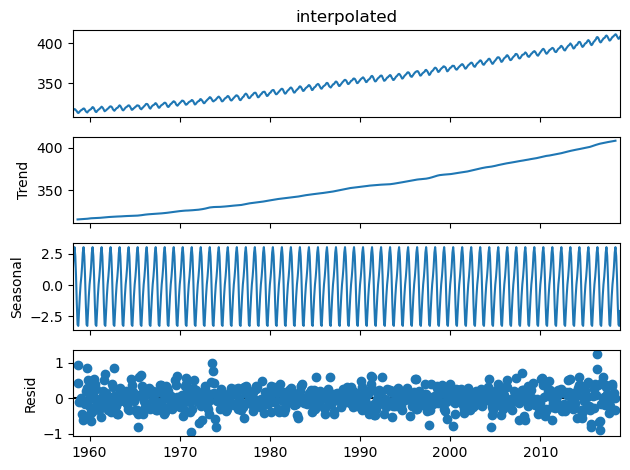

In [15]:
decomp.plot()
plt.show()

#### 4) Using Auto Arima to find (p,d,q) and (P,D,Q,m) for SARIMA Model:

In [16]:
model = auto_arima(y= df['interpolated'],
                  start_p= 0, start_q=0,
                  seasonal= True, m= 12,
                  start_P= 0, start_Q= 0,
                  trace= True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2369.532, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.71 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1614.808, Time=0.51 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2375.248, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1935.623, Time=0.14 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=428.799, Time=2.47 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=791.747, Time=0.55 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : AIC=430.828, Time=4.83 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=431.923, Time=4.94 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=1425.289, Time=1.78 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=617.368, Time=2.45 sec
 ARIMA(0,1,1)(2,0,2)[12] intercept   : AIC=inf, Time=8.10 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=1.88 sec
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=460.486, Time=2.12 sec
 ARIMA(0,1,2)(1,0,1)[12] intercept   : A

In [17]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  729
Model:             SARIMAX(2, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -206.257
Date:                            Thu, 18 Dec 2025   AIC                            424.514
Time:                                    19:25:36   BIC                            452.056
Sample:                                03-01-1958   HQIC                           435.141
                                     - 11-01-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3511      0.079      4.439      0.000       0.196       0.506
ar.L2          0.0864      0.029      2.970      0.003       0.029       0.143
ma.L1         -0.7057      0.064    -11.002      0.000      -0.831      -0.580
ar.S.L12       0.9996      0.000   3027.165      0.000       0.999       1.000
ma.S.L12      -0.8658      0.021    -40.864      0.000      -0.907      -0.824
sigma2         0.0956      0.005     21.132      0.000       0.087       0.104
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):                 4.44
Prob(Q):                              0.78   Prob(JB):                         0.11
Heteroskedasticity (H):               1.13   Skew:                            -0.00
Prob(H) (two-sided):                  0.35   Kurtosis:                         3.38
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

`(p,d,q)(P,D,Q,m) = (2,1,1)(1,0,1,12)`

#### 5) Train Test Split:

In [18]:
len(df)

729

In [19]:
train_data = df[:693]
test_data = df[693:]
print(train_data.shape, test_data.shape)

(693, 5) (36, 5)


#### 6) SARIMA(2,1,1)(1,0,1,12) Model:

In [21]:
sarima_model = SARIMAX(endog= df['interpolated'],
                      order= (2, 1, 1),
                      seasonal_order= (1, 0, 1, 12),)

result = sarima_model.fit()

C:\Users\shail\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [22]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                       interpolated   No. Observations:                  729
Model:             SARIMAX(2, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -206.257
Date:                            Thu, 18 Dec 2025   AIC                            424.514
Time:                                    19:29:45   BIC                            452.056
Sample:                                03-01-1958   HQIC                           435.141
                                     - 11-01-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3511      0.079      4.439      0.000       0.196       0.506
ar.L2          0.0864      0.029      2.970      0.003       0.029       0.143
ma.L1         -0.7057      0.064    -11.002      0.000      -0.831      -0.580
ar.S.L12       0.9996      0.000   3027.165      0.000       0.999       1.000
ma.S.L12      -0.8658      0.021    -40.864      0.000      -0.907      -0.824
sigma2         0.0956      0.005     21.132      0.000       0.087       0.104
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):                 4.44
Prob(Q):                              0.78   Prob(JB):                         0.11
Heteroskedasticity (H):               1.13   Skew:                            -0.00
Prob(H) (two-sided):                  0.35   Kurtosis:                         3.38
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

##### Predictions on Test Data and Evaluation:

In [23]:
start = len(train_data)

end = len(train_data) + len(test_data) - 1

In [24]:
# Predictions:

preds = result.predict(start= start,
                      end= end,
                      dynamic= False)

print(preds)

Date
2015-12-01    401.408460
2016-01-01    402.837669
2016-02-01    403.308365
2016-03-01    404.763099
2016-04-01    406.149948
2016-05-01    407.592179
2016-06-01    406.845101
2016-07-01    405.195565
2016-08-01    402.537822
2016-09-01    400.945065
2016-10-01    401.279201
2016-11-01    402.974338
2016-12-01    404.847279
2017-01-01    405.680996
2017-02-01    406.798394
2017-03-01    407.493515
2017-04-01    408.825633
2017-05-01    409.576709
2017-06-01    408.879427
2017-07-01    407.192280
2017-08-01    405.022002
2017-09-01    403.689086
2017-10-01    403.753128
2017-11-01    405.222677
2017-12-01    406.598901
2018-01-01    407.951159
2018-02-01    408.703843
2018-03-01    409.356053
2018-04-01    410.960525
2018-05-01    411.112325
2018-06-01    410.446412
2018-07-01    409.007690
2018-08-01    406.711671
2018-09-01    405.443335
2018-10-01    405.755831
2018-11-01    407.435709
Freq: MS, Name: predicted_mean, dtype: float64


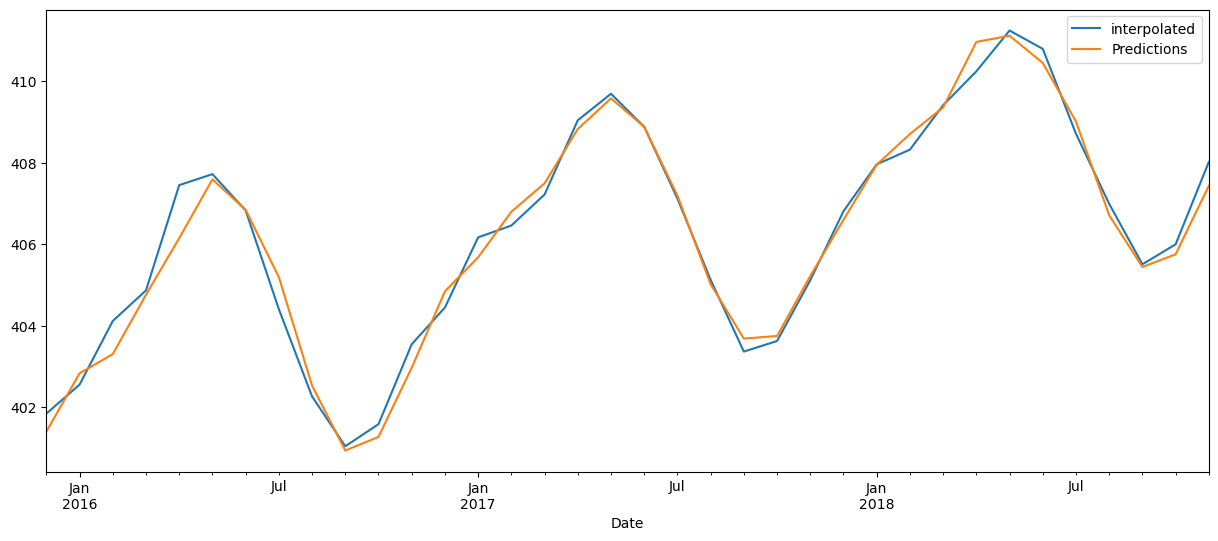

In [26]:
# Plotting Test Data and Predictions:

test_data['interpolated'].plot(figsize= (15,6), legend= True)
preds.plot(label= 'Predictions', legend= True)
plt.show()

In [27]:
# Model Evaluation:

np.sqrt(mean_squared_error(test_data['interpolated'], preds))

np.float64(0.4077780206521307)

#### 7) Training Model on Whole Data and Future Forecasting:

In [28]:
final_model = SARIMAX(endog= df['interpolated'],
                     order=(2, 1, 1),
                     seasonal_order= (1, 0, 1, 12))

result = final_model.fit()

C:\Users\shail\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [29]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                       interpolated   No. Observations:                  729
Model:             SARIMAX(2, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -206.257
Date:                            Thu, 18 Dec 2025   AIC                            424.514
Time:                                    19:33:32   BIC                            452.056
Sample:                                03-01-1958   HQIC                           435.141
                                     - 11-01-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3511      0.079      4.439      0.000       0.196       0.506
ar.L2          0.0864      0.029      2.970      0.003       0.029       0.143
ma.L1         -0.7057      0.064    -11.002      0.000      -0.831      -0.580
ar.S.L12       0.9996      0.000   3027.165      0.000       0.999       1.000
ma.S.L12      -0.8658      0.021    -40.864      0.000      -0.907      -0.824
sigma2         0.0956      0.005     21.132      0.000       0.087       0.104
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):                 4.44
Prob(Q):                              0.78   Prob(JB):                         0.11
Heteroskedasticity (H):               1.13   Skew:                            -0.00
Prob(H) (two-sided):                  0.35   Kurtosis:                         3.38
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [30]:
# Forecast:

forecast = result.predict(start= len(df),
                         end= len(df) + 24,
                         dynamic= False)

In [31]:
forecast

2018-12-01    409.257667
2019-01-01    410.415826
2019-02-01    411.077417
2019-03-01    411.992432
2019-04-01    413.443714
2019-05-01    414.095685
2019-06-01    413.358043
2019-07-01    411.615437
2019-08-01    409.566520
2019-09-01    408.112809
2019-10-01    408.412494
2019-11-01    410.010484
2019-12-01    411.440366
2020-01-01    412.629328
2020-02-01    413.318288
2020-03-01    414.245351
2020-04-01    415.702817
2020-05-01    416.357975
2020-06-01    415.622406
2020-07-01    413.881395
2020-08-01    411.833745
2020-09-01    410.380840
2020-10-01    410.680539
2020-11-01    412.277982
2020-12-01    413.707348
Freq: MS, Name: predicted_mean, dtype: float64

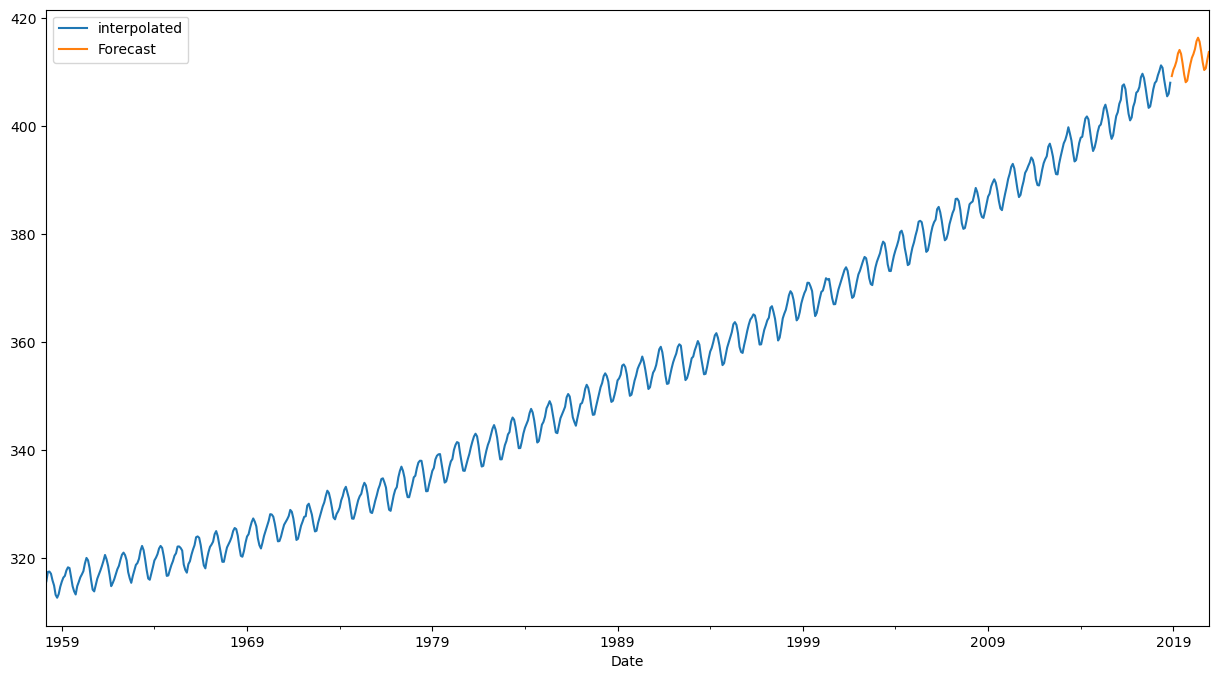

In [33]:
# Plotting Hostoric Data with Forecast:

df['interpolated'].plot(figsize= (15,8), legend= True)
forecast.plot(label= "Forecast", legend= True)
plt.show()